In [1]:
import networkx as nx 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import EoN
from tqdm import trange
import pandas as pd
import random
from sklearn.model_selection import train_test_split

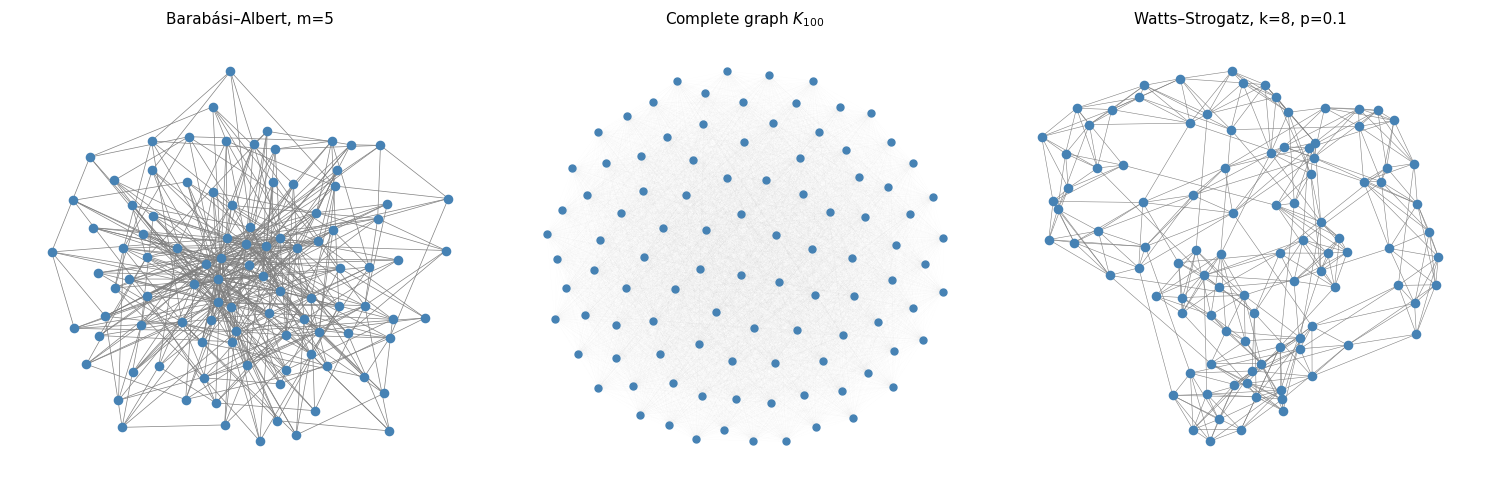

In [2]:
N_vis = 100
seed_layout = 42

G_ba = nx.barabasi_albert_graph(N_vis, 5, seed=seed_layout)
G_complete = nx.complete_graph(N_vis)
G_ws = nx.watts_strogatz_graph(N_vis, 8, 0.1, seed=seed_layout)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

graphs_titles = [
    (G_ba, "Barabási–Albert, m=5", dict(node_size=35, width=0.5)),
    (G_complete, "Complete graph $K_{100}$", dict(node_size=25, width=0.03, edge_color=(0.4, 0.4, 0.4, 0.12))),
    (G_ws, "Watts–Strogatz, k=8, p=0.1", dict(node_size=35, width=0.4)),
]

for ax, (G, title, draw_kw) in zip(axes, graphs_titles):
    pos = nx.spring_layout(G, seed=seed_layout, k=0.35)
    nx.draw(
        G, pos, ax=ax,
        with_labels=False,
        node_color="steelblue",
        edge_color=draw_kw.get("edge_color", "gray"),
        **{k: v for k, v in draw_kw.items() if k != "edge_color"},
    )
    ax.set_title(title, fontsize=11)
    ax.axis("off")

plt.tight_layout()
plt.show()


In [3]:
def SEIR_network_with_poisson(G, tau, alpha, gamma, rho, tmax, lam):
    """SEIR на графе с внешним импортом: каждый день число новых E ~ Poisson(lam) среди узлов,
    которые в начале дня были восприимчивы (S). Сетевые переходы считаются по тем же состояниям."""
    for node in G.nodes():
        G.nodes[node]['state'] = 0

    initial_infected = int(rho * len(G.nodes()))
    initial_infected_nodes = random.sample(list(G.nodes()), initial_infected)
    for node in initial_infected_nodes:
        G.nodes[node]['state'] = 2

    susceptible_count = []
    exposed_count = []
    infected_count = []
    recovered_count = []

    for day in range(tmax + 1):
        new_states = {}

        susceptible = sum(1 for n in G.nodes if G.nodes[n]['state'] == 0)
        exposed = sum(1 for n in G.nodes if G.nodes[n]['state'] == 1)
        infected = sum(1 for n in G.nodes if G.nodes[n]['state'] == 2)
        recovered = sum(1 for n in G.nodes if G.nodes[n]['state'] == 3)

        susceptible_count.append(susceptible)
        exposed_count.append(exposed)
        infected_count.append(infected)
        recovered_count.append(recovered)

        # Рассматриваем только восприимчивые узлы
        susceptibles = [n for n in G.nodes if G.nodes[n]['state'] == 0]
        k = np.random.poisson(lam)
        if k > 0 and susceptibles:
            k = min(int(k), len(susceptibles))
            for node in random.sample(susceptibles, k):
                new_states[node] = 1

        for node in G.nodes():
            state = G.nodes[node]['state']
            if state == 2:
                for neighbor in G.neighbors(node):
                    if G.nodes[neighbor]['state'] == 0:
                        if random.random() < tau:
                            new_states[neighbor] = 1
                if random.random() < gamma:
                    new_states[node] = 3
            elif state == 1:
                if random.random() < alpha:
                    new_states[node] = 2

        for node, new_state in new_states.items():
            G.nodes[node]['state'] = new_state

    return [index for index in range(tmax + 1)], susceptible_count, exposed_count, infected_count, recovered_count


In [5]:
N = 10**4

tmax = 250
iterations = 50  # run 5 simulations
tau_boundaries = np.arange(0.01, 0.06, 0.01)         # transmission rate
gamma = 0.08  # recovery rate
rho_boundaries = np.arange(0.005, 0.011, 0.001)     # random fraction initially infected
alpha = 0.1 # latent period rate
lam_boundaries = np.arange(0, 101, 10)

# barabasi_albert_graph

In [4]:
# parameters for the network

N = 10**4

G = nx.barabasi_albert_graph(N, 5)
#G = nx.complete_graph(N)
#G = nx.watts_strogatz_graph(N, 8, 0.1)
#G = nx.complete_graph(N)

tmax = 250
iterations = 50  # run 5 simulations
tau_boundaries = np.arange(0.01, 0.06, 0.01)         # transmission rate
gamma = 0.08  # recovery rate
rho_boundaries = np.arange(0.005, 0.011, 0.001)     # random fraction initially infected
alpha = 0.1 # latent period rate
lam_boundaries = np.arange(0, 101, 10)

seed = 0
for lam in lam_boundaries:
    for tau in tau_boundaries:
        for rho in rho_boundaries:
            print('---')


            #fig, ax = plt.subplots(1, 1, figsize=(6, 4))
            #ax_beta = ax.twinx()
            for iter in range(0, 50):
                # SEIR
                t, S, E, I, R = SEIR_network_with_poisson(G, tau, alpha, gamma, rho, tmax, lam)

                S = np.array(S)
                E = np.array(E)
                I = np.array(I)
                R = np.array(R)

                #ax.plot(t, I, color = 'k', alpha=0.3)

                # compute betas values
                beta_values = []
                num_days = len(t)
                for i in range(num_days - 1):
                    if S[i] > 0 and I[i] > 0:
                        beta = - (S[i + 1] - S[i]) / (S[i] * I[i])
                    else:
                        beta = np.nan
                    beta_values.append(beta)
                beta_values.append(np.nan)
                #ax_beta.plot(beta_values, color='lightgray', alpha=0.5)
                # store the simulation results in a dataFrame
                df_sim = pd.DataFrame({
                "S": S,
                "E": E,
                "I": I,
                "R": R,
                "Beta": beta_values
                })
                # save the results to a csv file
                output_file = f"seir_seed_{seed}.csv"
                df_sim.to_csv(f'Data/new/barabasi_albert_graph/lam={int(lam)}/{output_file}', index=False)
                print(seed)
                seed += 1      

print('END')

---
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
---
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
---
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
---
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
---
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
---
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
27

# complete_graph

In [10]:
G = nx.complete_graph(N)

seed = 0
for lam in lam_boundaries:
    for tau in tau_boundaries:
        for rho in rho_boundaries:
            print('---')


            #fig, ax = plt.subplots(1, 1, figsize=(6, 4))
            #ax_beta = ax.twinx()
            #for iter in range(0, 50):
            for iter in range(0,5):
                # SEIR
                t, S, E, I, R = SEIR_network_with_poisson(G, tau, alpha, gamma, rho, tmax, lam)

                S = np.array(S)
                E = np.array(E)
                I = np.array(I)
                R = np.array(R)

                #ax.plot(t, I, color = 'k', alpha=0.3)

                # compute betas values
                beta_values = []
                num_days = len(t)
                for i in range(num_days - 1):
                    if S[i] > 0 and I[i] > 0:
                        beta = - (S[i + 1] - S[i]) / (S[i] * I[i])
                    else:
                        beta = np.nan
                    beta_values.append(beta)
                beta_values.append(np.nan)
                #ax_beta.plot(beta_values, color='lightgray', alpha=0.5)
                # store the simulation results in a dataFrame
                df_sim = pd.DataFrame({
                "S": S,
                "E": E,
                "I": I,
                "R": R,
                "Beta": beta_values
                })
                # save the results to a csv file
                output_file = f"seir_seed_{seed}.csv"
                df_sim.to_csv(f'Data/new/complete_graph/lam={int(lam)}/{output_file}', index=False)
                print(seed)
                seed += 1      

print('END')

---


KeyboardInterrupt: 

# watts_strogatz_graph

In [8]:
G = nx.watts_strogatz_graph(N, 8, 0.1)

seed = 0
for lam in lam_boundaries:
    for tau in tau_boundaries:
        for rho in rho_boundaries:
            print('---')


            #fig, ax = plt.subplots(1, 1, figsize=(6, 4))
            #ax_beta = ax.twinx()
            for iter in range(0, 50):
                # SEIR
                t, S, E, I, R = SEIR_network_with_poisson(G, tau, alpha, gamma, rho, tmax, lam)

                S = np.array(S)
                E = np.array(E)
                I = np.array(I)
                R = np.array(R)

                #ax.plot(t, I, color = 'k', alpha=0.3)

                # compute betas values
                beta_values = []
                num_days = len(t)
                for i in range(num_days - 1):
                    if S[i] > 0 and I[i] > 0:
                        beta = - (S[i + 1] - S[i]) / (S[i] * I[i])
                    else:
                        beta = np.nan
                    beta_values.append(beta)
                beta_values.append(np.nan)
                #ax_beta.plot(beta_values, color='lightgray', alpha=0.5)
                # store the simulation results in a dataFrame
                df_sim = pd.DataFrame({
                "S": S,
                "E": E,
                "I": I,
                "R": R,
                "Beta": beta_values
                })
                # save the results to a csv file
                output_file = f"seir_seed_{seed}.csv"
                df_sim.to_csv(f'Data/new/watts_strogatz_graph/lam={int(lam)}/{output_file}', index=False)
                print(seed)
                seed += 1      

print('END')

---
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
---
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
---
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
---
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
---
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
---
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
27

Generate csv-file with value of parameters for every seeds

In [42]:
'''
iterations = 50  # run 5 simulations
tau_boundaries = np.arange(0.01, 0.06, 0.01)         # transmission rate
gamma = 0.08  # recovery rate
rho_boundaries = np.arange(0.005, 0.011, 0.001)     # random fraction initially infected
alpha = 0.1 # latent period rate
seed_number = 0
parameters = pd.DataFrame(columns = ['seed_number','tau', 'rho'])
for tau in tau_boundaries:
    for rho in rho_boundaries:
        for iter in range(0, iterations):
            parameters = pd.concat([parameters,pd.DataFrame({'seed_number':[seed_number],'tau':[tau],'rho':[rho]})],ignore_index=True)
            seed_number += 1 

# save the results to a csv file
parameters.to_csv('initial data/seeds_parameters.csv', index=False)
print('END')
'''

"\niterations = 50  # run 5 simulations\ntau_boundaries = np.arange(0.01, 0.06, 0.01)         # transmission rate\ngamma = 0.08  # recovery rate\nrho_boundaries = np.arange(0.005, 0.011, 0.001)     # random fraction initially infected\nalpha = 0.1 # latent period rate\nseed_number = 0\nparameters = pd.DataFrame(columns = ['seed_number','tau', 'rho'])\nfor tau in tau_boundaries:\n    for rho in rho_boundaries:\n        for iter in range(0, iterations):\n            parameters = pd.concat([parameters,pd.DataFrame({'seed_number':[seed_number],'tau':[tau],'rho':[rho]})],ignore_index=True)\n            seed_number += 1 \n\n# save the results to a csv file\nparameters.to_csv('initial data/seeds_parameters.csv', index=False)\nprint('END')\n"

Train-val-test split seeds numbers

In [50]:
df = pd.read_csv('Data/initial data/seeds_parameters.csv')
X = df.drop(columns=['tau', 'rho'])
y = df[['tau', 'rho']]
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42, stratify=y)
y = y.loc[X_train.index]
X_train, X_val = train_test_split(X_train, test_size=0.2, random_state=42, stratify=y)
X_train = X_train.sort_values(by = ['seed_number'])
X_val = X_val.sort_values(by = ['seed_number'])
X_test = X_test.sort_values(by = ['seed_number'])

Sharing the seeds on train and test and generate csv-file with value of initial and finite indexies

In [51]:
train_index = pd.DataFrame(columns = ['initial','finite'])
for i, seed_number in enumerate(X_train['seed_number'].values):
    #df = pd.read_csv(f'Data/initial data/seir_seed_{seed_number}.csv')
    df = pd.read_csv(f'initial data/seir_seed_{seed_number}.csv')
    df = df.iloc[:-1]
    train_index = pd.concat([train_index, pd.DataFrame({'initial':[seed_number],'finite':[i]})],ignore_index=True)
    df.fillna(0, inplace=True)
    df.to_csv(f'train/seir_seed_{i}.csv', index=False)
train_index.to_csv('train/train_index.csv',index=False)

val_index = pd.DataFrame(columns = ['initial','finite'])
for i, seed_number in enumerate(X_val['seed_number'].values):
    df = pd.read_csv(f'initial data/seir_seed_{seed_number}.csv')
    df = df.iloc[:-1]
    val_index = pd.concat([val_index, pd.DataFrame({'initial':[seed_number],'finite':[i]})],ignore_index=True)
    df.fillna(0, inplace=True)
    df.to_csv(f'val/seir_seed_{i}.csv', index=False)
val_index.to_csv('val/val_index.csv',index=False)

test_index = pd.DataFrame(columns = ['initial','finite'])
for i, seed_number in enumerate(X_test['seed_number'].values):
    df = pd.read_csv(f'initial data/seir_seed_{seed_number}.csv')
    df = df.iloc[:-1]
    test_index = pd.concat([test_index, pd.DataFrame({'initial':[seed_number],'finite':[i]})],ignore_index=True)
    df.fillna(0, inplace=True)
    df.to_csv(f'test/seir_seed_{i}.csv', index=False)
test_index.to_csv('test/test_index.csv',index=False)



Generate csv-file with median Beta values

In [52]:
betas = pd.DataFrame()

for i in range(X_train.shape[0]):
    df = pd.read_csv(f'train/seir_seed_{i}.csv')
    epidemic_end = df[(df['E'] == 0) & (df['I'] == 0)].index
    if epidemic_end.shape[0] > 1:
        df.loc[epidemic_end[0]:, 'Beta'] = -2  # поправил на df.loc[...] вместо df['Beta'].loc[...]
    
    df = df[['Beta']]
    df.columns = [i]  # Переименовываем колонку 'Beta' в номер сида
    betas = pd.concat([betas, df], axis=1)

median_beta = betas[betas > 0].median(axis=1)
median_beta.to_csv('train/median_beta.csv', header=['median_beta'])

Research of Infected values for every seed

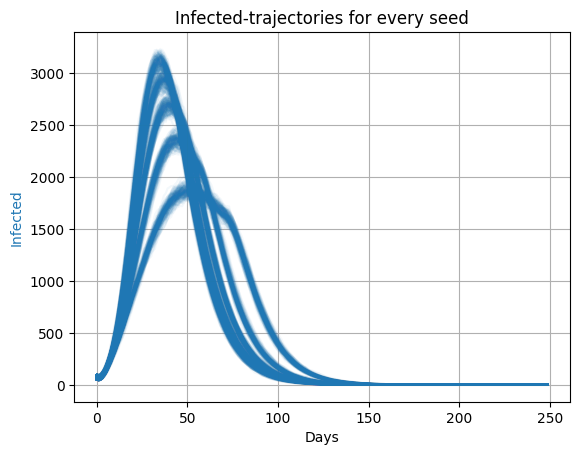

In [55]:
for i in np.arange(0,960):
    df = pd.read_csv(f'train/seir_seed_{i}.csv')
    plt.plot(np.arange(0,250), df['I'].values, alpha=0.05, color = 'tab:blue')
plt.xlabel('Days')
plt.ylabel('Infected', color='tab:blue')
plt.title('Infected-trajectories for every seed')
#plt.ylim([0,500])
plt.grid()
plt.show()



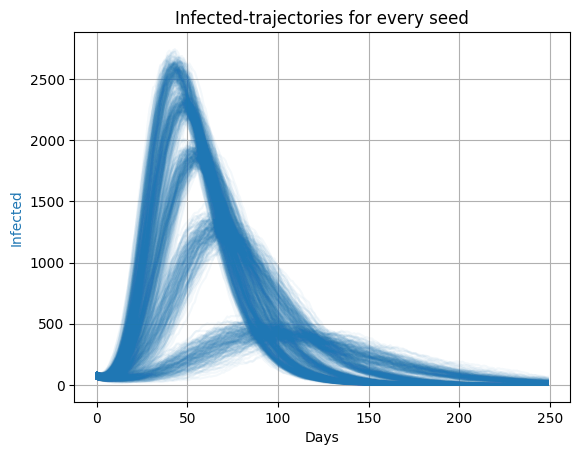

In [21]:
for i in np.arange(0,960):
    df = pd.read_csv(f'train/seir_seed_{i}.csv')
    plt.plot(np.arange(0,250), df['I'].values, alpha=0.05, color = 'tab:blue')
plt.xlabel('Days')
plt.ylabel('Infected', color='tab:blue')
plt.title('Infected-trajectories for every seed')
#plt.ylim([0,500])
plt.grid()
plt.show()



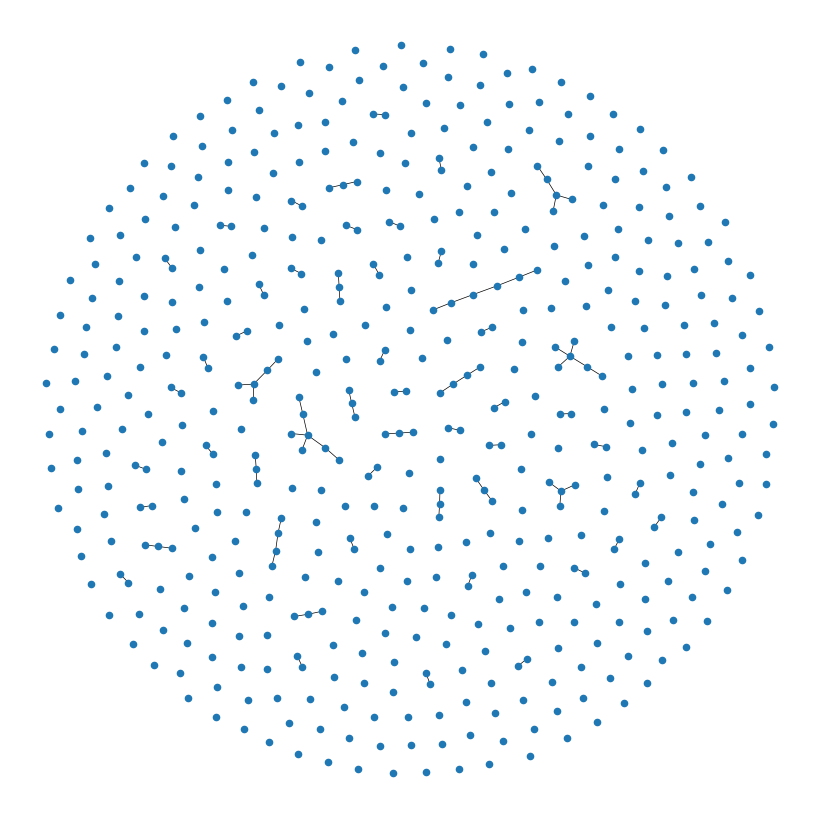

In [36]:
import random

n_sample = 500
nodes = random.sample(list(G.nodes()), min(n_sample, G.number_of_nodes()))
H = G.subgraph(nodes).copy()
pos = nx.spring_layout(H, seed=42)
plt.figure(figsize=(8, 8))
nx.draw(H, pos, node_size=20, width=0.5, with_labels=False)
plt.show()

In [11]:
df = pd.read_csv('Data/initial data/seeds_parameters.csv')
X = df.drop(columns=['tau', 'rho'])
y = df[['tau', 'rho']]
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42, stratify=y)
y = y.loc[X_train.index]
X_train, X_val = train_test_split(X_train, test_size=0.2, random_state=42, stratify=y)
X_train = X_train.sort_values(by = ['seed_number'])
X_val = X_val.sort_values(by = ['seed_number'])
X_test = X_test.sort_values(by = ['seed_number'])

train_index = pd.DataFrame(columns = ['initial','finite'])
for i, seed_number in enumerate(X_train['seed_number'].values):
    #df = pd.read_csv(f'Data/initial data/seir_seed_{seed_number}.csv')
    df = pd.read_csv(f'initial data/seir_seed_{seed_number}.csv')
    df = df.iloc[:-1]
    train_index = pd.concat([train_index, pd.DataFrame({'initial':[seed_number],'finite':[i]})],ignore_index=True)
    df.fillna(0, inplace=True)
    df.to_csv(f'train/seir_seed_{i}.csv', index=False)
train_index.to_csv('train/train_index.csv',index=False)

val_index = pd.DataFrame(columns = ['initial','finite'])
for i, seed_number in enumerate(X_val['seed_number'].values):
    df = pd.read_csv(f'initial data/seir_seed_{seed_number}.csv')
    df = df.iloc[:-1]
    val_index = pd.concat([val_index, pd.DataFrame({'initial':[seed_number],'finite':[i]})],ignore_index=True)
    df.fillna(0, inplace=True)
    df.to_csv(f'val/seir_seed_{i}.csv', index=False)
val_index.to_csv('val/val_index.csv',index=False)

test_index = pd.DataFrame(columns = ['initial','finite'])
for i, seed_number in enumerate(X_test['seed_number'].values):
    df = pd.read_csv(f'initial data/seir_seed_{seed_number}.csv')
    df = df.iloc[:-1]
    test_index = pd.concat([test_index, pd.DataFrame({'initial':[seed_number],'finite':[i]})],ignore_index=True)
    df.fillna(0, inplace=True)
    df.to_csv(f'test/seir_seed_{i}.csv', index=False)
test_index.to_csv('test/test_index.csv',index=False)

betas = pd.DataFrame()

for i in range(X_train.shape[0]):
    df = pd.read_csv(f'train/seir_seed_{i}.csv')
    epidemic_end = df[(df['E'] == 0) & (df['I'] == 0)].index
    if epidemic_end.shape[0] > 1:
        df.loc[epidemic_end[0]:, 'Beta'] = -2  # поправил на df.loc[...] вместо df['Beta'].loc[...]
    
    df = df[['Beta']]
    df.columns = [i]  # Переименовываем колонку 'Beta' в номер сида
    betas = pd.concat([betas, df], axis=1)

median_beta = betas[betas > 0].median(axis=1)
median_beta.to_csv('train/median_beta.csv', header=['median_beta'])

for i in np.arange(0,960):
    df = pd.read_csv(f'train/seir_seed_{i}.csv')
    plt.plot(np.arange(0,250), df['I'].values, alpha=0.05, color = 'tab:blue')
plt.xlabel('Days')
plt.ylabel('Infected', color='tab:blue')
plt.title('Infected-trajectories for every seed')
#plt.ylim([0,500])
plt.grid()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'Data/initial data/seeds_parameters.csv'

In [ ]:
df = pd.read_csv('Data/initial data/seeds_parameters.csv')
X = df.drop(columns=['tau', 'rho'])
y = df[['tau', 'rho']]
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42, stratify=y)
y = y.loc[X_train.index]
X_train, X_val = train_test_split(X_train, test_size=0.2, random_state=42, stratify=y)
X_train = X_train.sort_values(by = ['seed_number'])
X_val = X_val.sort_values(by = ['seed_number'])
X_test = X_test.sort_values(by = ['seed_number'])

train_index = pd.DataFrame(columns = ['initial','finite'])
for i, seed_number in enumerate(X_train['seed_number'].values):
    #df = pd.read_csv(f'Data/initial data/seir_seed_{seed_number}.csv')
    df = pd.read_csv(f'initial data/seir_seed_{seed_number}.csv')
    df = df.iloc[:-1]
    train_index = pd.concat([train_index, pd.DataFrame({'initial':[seed_number],'finite':[i]})],ignore_index=True)
    df.fillna(0, inplace=True)
    df.to_csv(f'train/seir_seed_{i}.csv', index=False)
train_index.to_csv('train/train_index.csv',index=False)

val_index = pd.DataFrame(columns = ['initial','finite'])
for i, seed_number in enumerate(X_val['seed_number'].values):
    df = pd.read_csv(f'initial data/seir_seed_{seed_number}.csv')
    df = df.iloc[:-1]
    val_index = pd.concat([val_index, pd.DataFrame({'initial':[seed_number],'finite':[i]})],ignore_index=True)
    df.fillna(0, inplace=True)
    df.to_csv(f'val/seir_seed_{i}.csv', index=False)
val_index.to_csv('val/val_index.csv',index=False)

test_index = pd.DataFrame(columns = ['initial','finite'])
for i, seed_number in enumerate(X_test['seed_number'].values):
    df = pd.read_csv(f'initial data/seir_seed_{seed_number}.csv')
    df = df.iloc[:-1]
    test_index = pd.concat([test_index, pd.DataFrame({'initial':[seed_number],'finite':[i]})],ignore_index=True)
    df.fillna(0, inplace=True)
    df.to_csv(f'test/seir_seed_{i}.csv', index=False)
test_index.to_csv('test/test_index.csv',index=False)

betas = pd.DataFrame()

for i in range(X_train.shape[0]):
    df = pd.read_csv(f'train/seir_seed_{i}.csv')
    epidemic_end = df[(df['E'] == 0) & (df['I'] == 0)].index
    if epidemic_end.shape[0] > 1:
        df.loc[epidemic_end[0]:, 'Beta'] = -2  # поправил на df.loc[...] вместо df['Beta'].loc[...]
    
    df = df[['Beta']]
    df.columns = [i]  # Переименовываем колонку 'Beta' в номер сида
    betas = pd.concat([betas, df], axis=1)

median_beta = betas[betas > 0].median(axis=1)
median_beta.to_csv('train/median_beta.csv', header=['median_beta'])

for i in np.arange(0,960):
    df = pd.read_csv(f'train/seir_seed_{i}.csv')
    plt.plot(np.arange(0,250), df['I'].values, alpha=0.05, color = 'tab:blue')
plt.xlabel('Days')
plt.ylabel('Infected', color='tab:blue')
plt.title('Infected-trajectories for every seed')
#plt.ylim([0,500])
plt.grid()
plt.show()

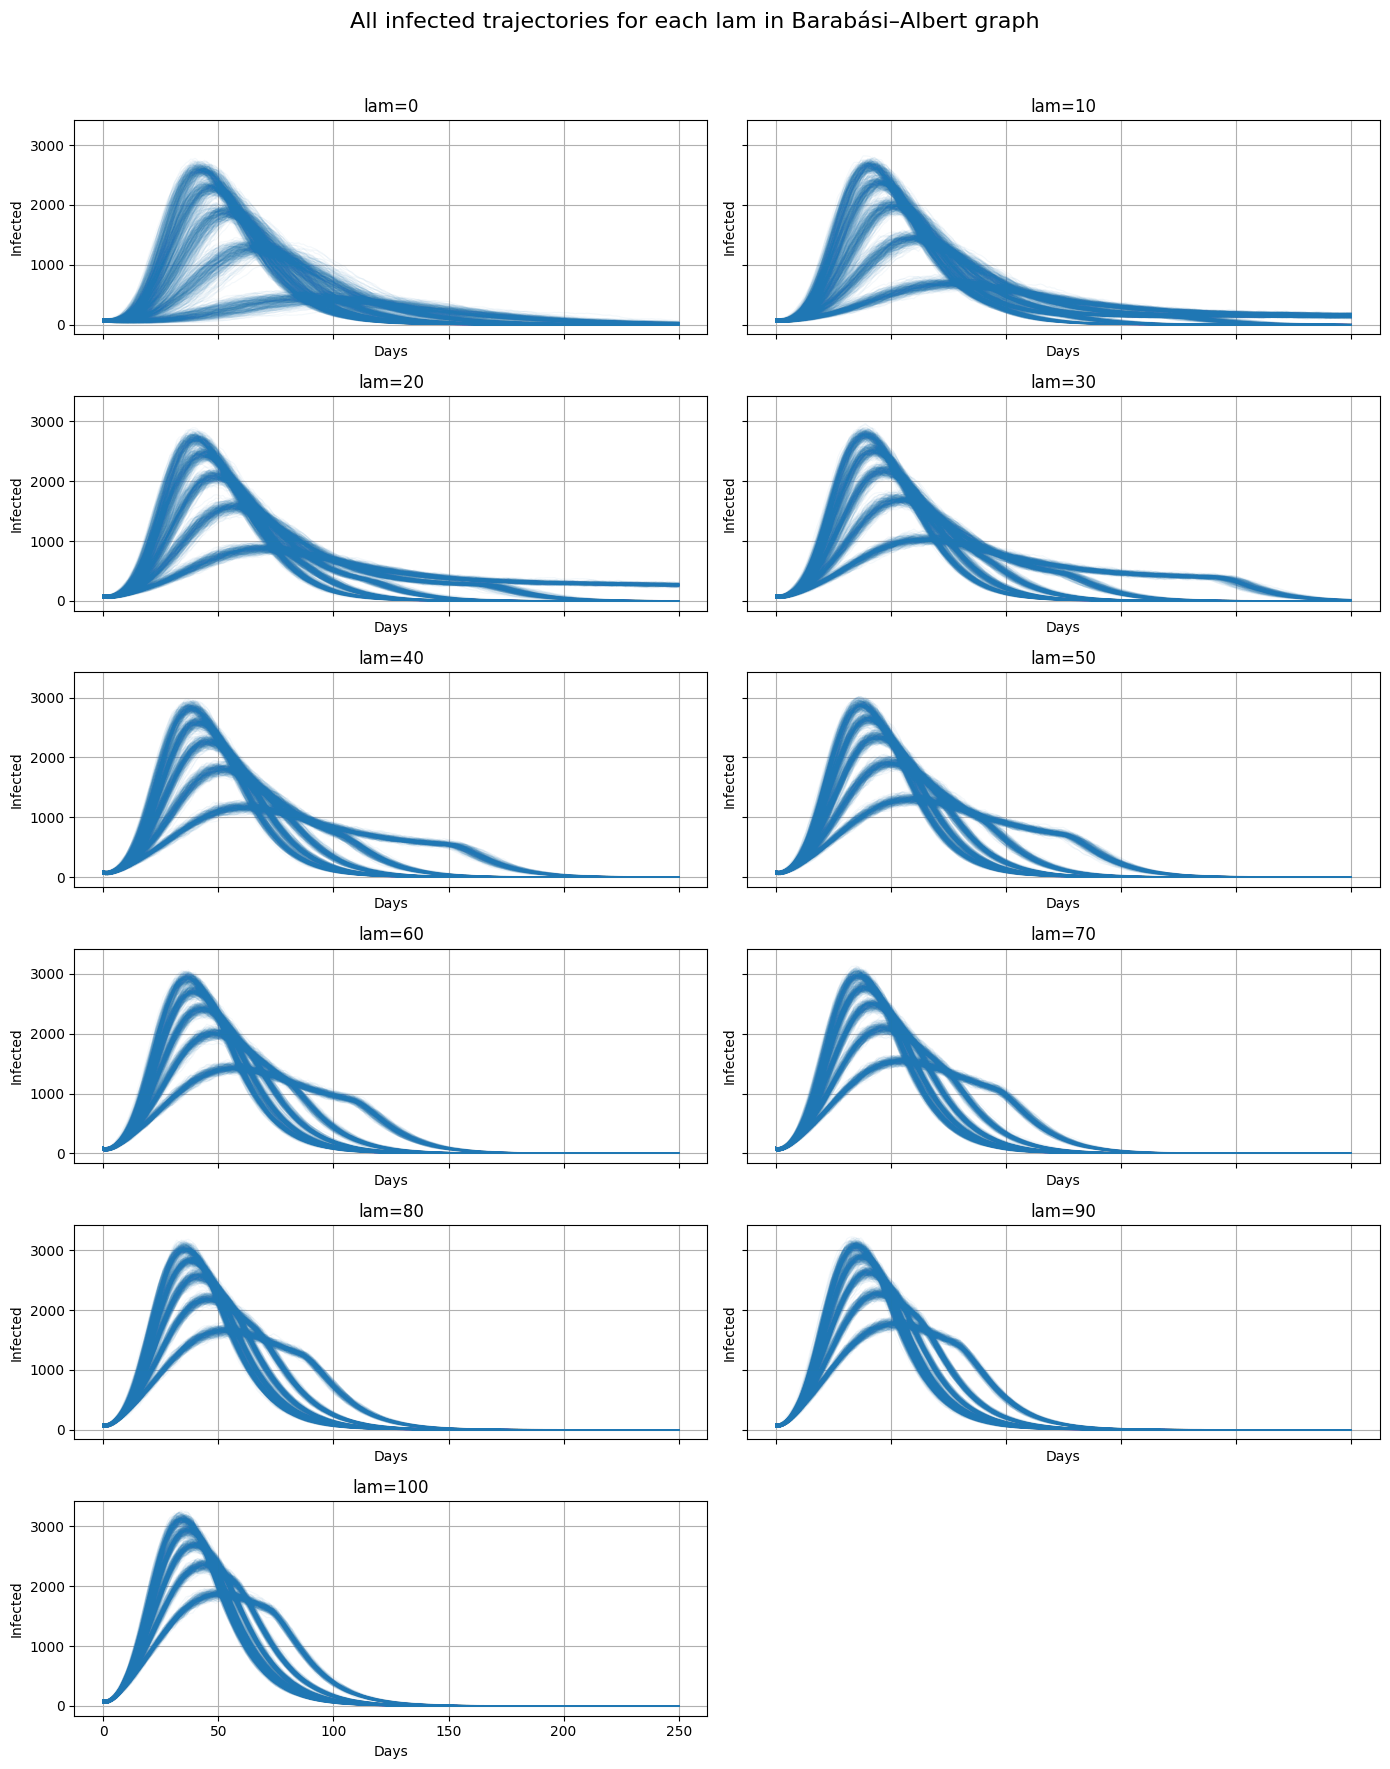

In [14]:
import glob
import os
import math

base_dir = 'Data/new/barabasi_albert_graph'
lam_dirs = sorted(
    glob.glob(os.path.join(base_dir, 'lam=*')),
    key=lambda p: int(os.path.basename(p).split('=')[1])
)

n_lam = len(lam_dirs)
if n_lam == 0:
    raise ValueError(f'No lam directories found in {base_dir}')

ncols = 2
nrows = math.ceil(n_lam / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for ax, lam_dir in zip(axes, lam_dirs):
    lam_value = int(os.path.basename(lam_dir).split('=')[1])
    seed_files = sorted(glob.glob(os.path.join(lam_dir, 'seir_seed_*.csv')))
    if not seed_files:
        ax.set_title(f'lam={lam_value} (no files)')
        continue

    for path in seed_files:
        df = pd.read_csv(path)
        if 'I' not in df.columns:
            continue
        ax.plot(df['I'].to_numpy(), alpha=0.05, color='tab:blue', linewidth=0.8)

    ax.set_title(f'lam={lam_value}')
    ax.set_xlabel('Days')
    ax.set_ylabel('Infected')
    ax.grid(True)
for ax in axes[n_lam:]:
    fig.delaxes(ax)

fig.suptitle('All infected trajectories for each lam in Barabási–Albert graph', fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

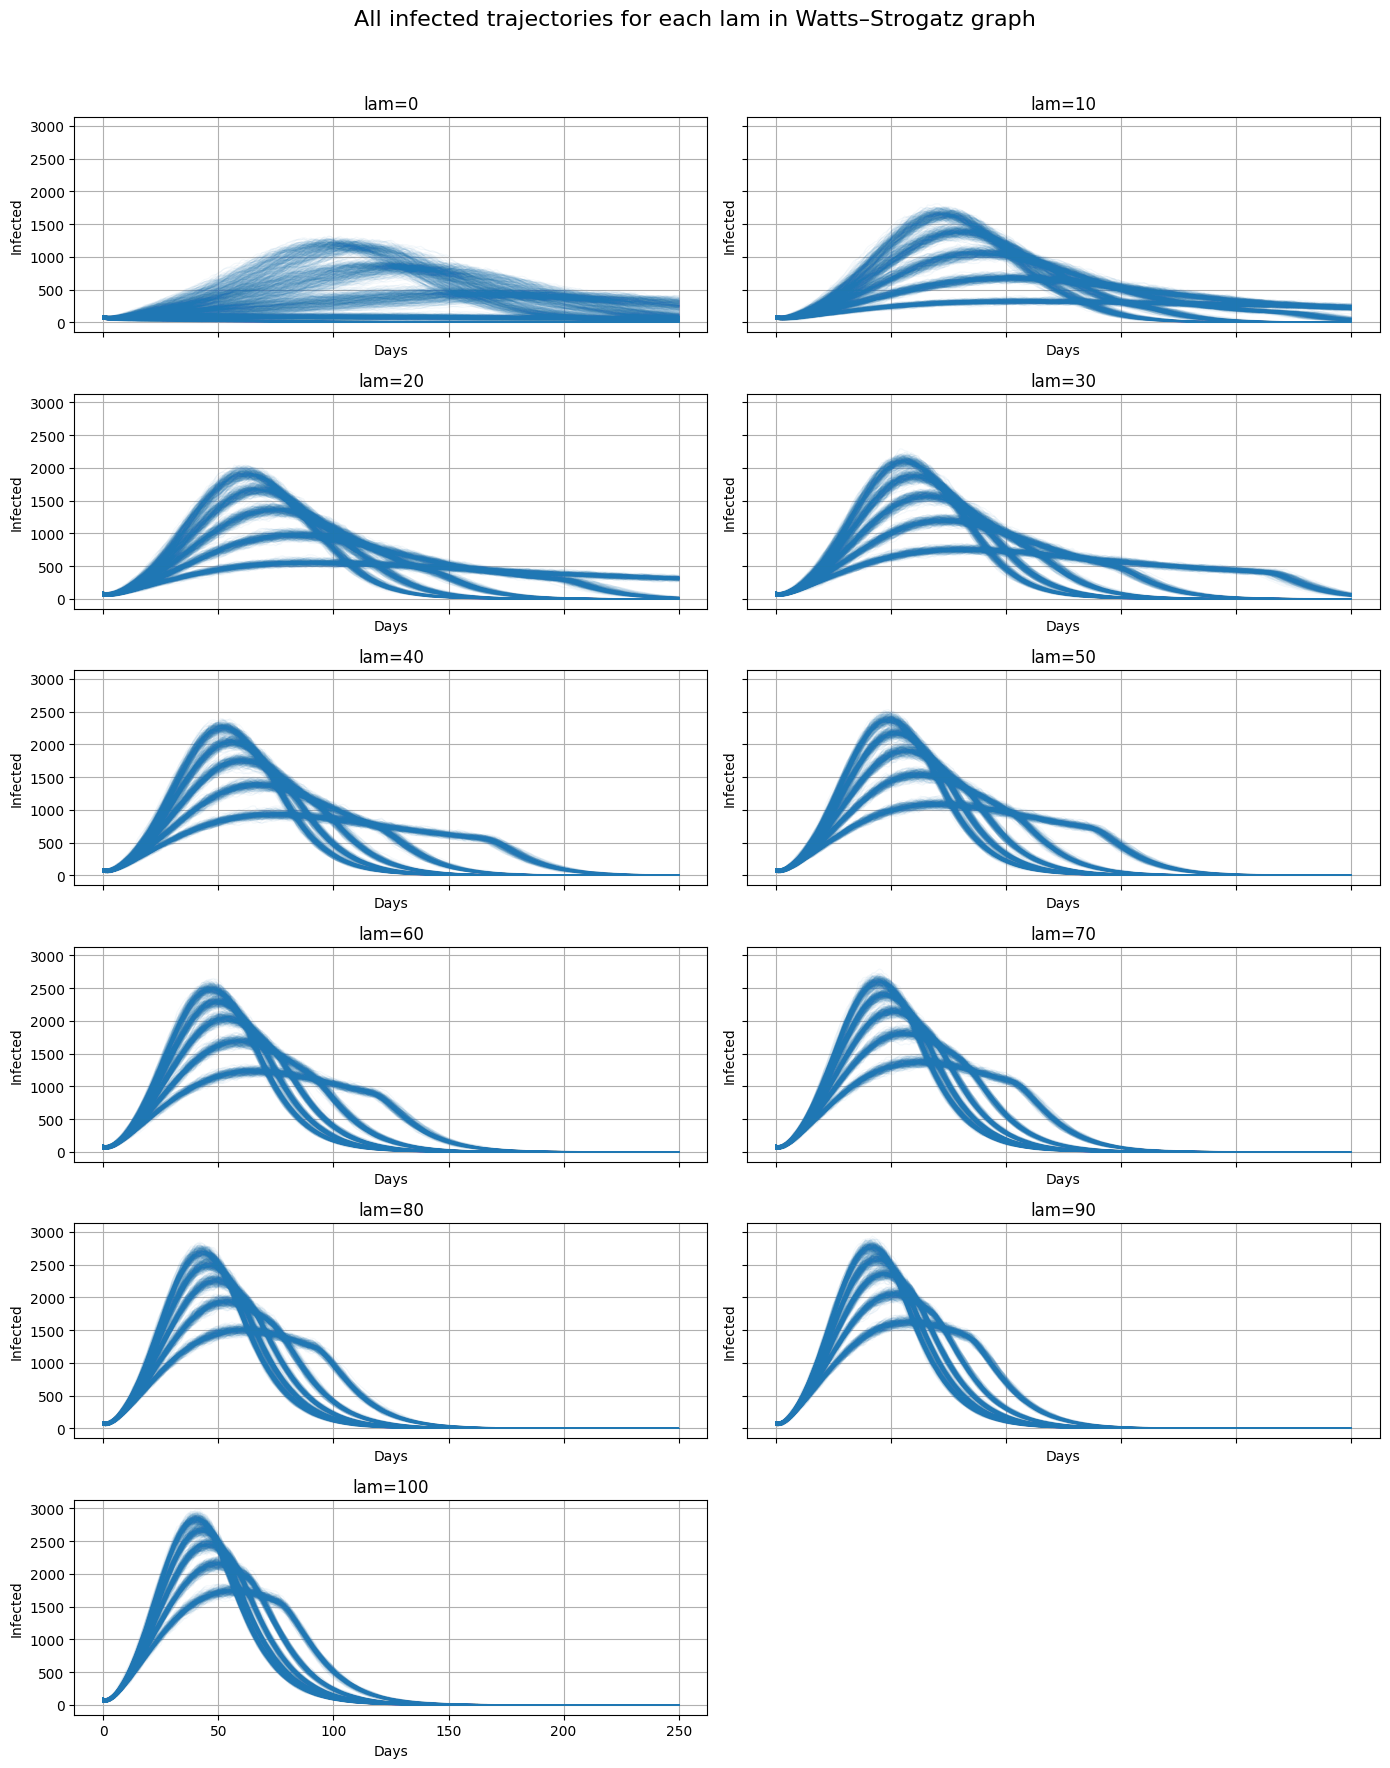

In [15]:
import glob
import os
import math

base_dir = 'Data/new/watts_strogatz_graph'
lam_dirs = sorted(
    glob.glob(os.path.join(base_dir, 'lam=*')),
    key=lambda p: int(os.path.basename(p).split('=')[1])
)

n_lam = len(lam_dirs)
if n_lam == 0:
    raise ValueError(f'No lam directories found in {base_dir}')

ncols = 2
nrows = math.ceil(n_lam / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for ax, lam_dir in zip(axes, lam_dirs):
    lam_value = int(os.path.basename(lam_dir).split('=')[1])
    seed_files = sorted(glob.glob(os.path.join(lam_dir, 'seir_seed_*.csv')))
    if not seed_files:
        ax.set_title(f'lam={lam_value} (no files)')
        continue

    for path in seed_files:
        df = pd.read_csv(path)
        if 'I' not in df.columns:
            continue
        ax.plot(df['I'].to_numpy(), alpha=0.05, color='tab:blue', linewidth=0.8)

    ax.set_title(f'lam={lam_value}')
    ax.set_xlabel('Days')
    ax.set_ylabel('Infected')
    ax.grid(True)
for ax in axes[n_lam:]:
    fig.delaxes(ax)

fig.suptitle('All infected trajectories for each lam in Watts–Strogatz graph', fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
import glob
import os

base_dir = 'Data/new/barabasi_albert_graph'
lam_dirs = sorted(
    glob.glob(os.path.join(base_dir, 'lam=*')),
    key=lambda p: int(os.path.basename(p).split('=')[1])
)

plt.figure(figsize=(12, 7))
for lam_dir in lam_dirs:
    lam_value = int(os.path.basename(lam_dir).split('=')[1])
    seed_files = sorted(glob.glob(os.path.join(lam_dir, 'seir_seed_*.csv')))
    if not seed_files:
        continue

    trajectories = []
    for path in seed_files:
        df = pd.read_csv(path)
        if 'I' not in df.columns:
            continue
        trajectories.append(df['I'].to_numpy())

    if not trajectories:
        continue

    lengths = [len(arr) for arr in trajectories]
    max_len = max(lengths)
    padded = np.full((len(trajectories), max_len), np.nan)
    for i, arr in enumerate(trajectories):
        padded[i, :len(arr)] = arr

    mean_I = np.nanmean(padded, axis=0)
    plt.plot(np.arange(len(mean_I)), mean_I, label=f'lam={lam_value}')

plt.xlabel('Days')
plt.ylabel('Infected')
plt.title('Mean infected trajectories for Barabási–Albert graph by lam')
plt.legend(title='lam', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()